# Hamiltonian Simulation

## README:
This notebook demonstrate Hamiltonian Simulation. 
1. The Hamiltonian is described in a list "Ham_list" and shown in output of the "Example 1" box. 
2. The circuit is constructed according to given Hamiltonian and t, r parameters, shown after box "The circuit"
3. A classical run is done using Qutip, both the result of the quantum run and the classical run is shown in output after box "Result, both quantum and classical"
4. Error is measured by norm(vector_quantum - vector_classic), with the parameter I used in the first example it is less than 1%
5. The relation between error, t and r is investigated in the "Example 2, error~(r, t) relation"
6. The example 3 demonstrated the relation of error~t when r = t^2/epsilon, showning when r = t^2/epsilon, the error rate is indeed around epsilon
7. The example 4 show Hamiltonian simulation in all $Z_iZ_{i+1}$ circuit is indeed errorless

## Initialization

In [1]:
from qiskit import *
import numpy as np
import warnings
from qiskit_aer import AerSimulator
import qutip as qt
from tqdm import tqdm



def make_tensor(element, num_qubit):
    """
    The function that generate the matrix of a Pauli operating on specific qubit(s) according to the element in Ham_list, the output format is a qutip qobj [[]*num_qubit]

    Parameter(s):
        element: the element in Ham_list that indecate what to add, simply put a tupel in Ham_list
        num_qubit: the number of qubits, so that the demention of the matrix is correct

    Return(s):
        H: the matrix of the Pauli operator
    """
    if element[0] == 'ZZ':  # in the case of 'ZZ'
        for i in range(num_qubit):  # loop over all qubits
            if i == element[1][0] or i == element[1][1]:  # when the qubit is the qubit that the operator can act on
                temp = qt.sigmaz()
            else:  # other wise just add identity
                temp = qt.qeye(2)
            if i == 0:  # if this is the first qubit we simply make H = tensor
                H = temp
            else:  # when this qubit is not the first qubit, tensor H and tensor.
                H = qt.tensor(H, temp)
    elif element[0] == 'gX':  # in the case of 'gX', the logic is similar to that of the above.
        for i in range(num_qubit):
            if i == element[2]:
                temp = qt.sigmax() * element[1]
            else:
                temp = qt.qeye(2)
            if i == 0:
                H = temp
            else:
                H = qt.tensor(H, temp)
    return H


def make_measurement_basis(num_qubit):
    """
    This function make all the measurment basis in the correct format.

    Paramenter(s):
        num_qubit: the number of qubits in the system

    Return(s):
        measurement_basis: a list of all the measurement basis in the correct format
    """
    measurement_basis = []
    key_list = [format(i, f'0{num_qubit}b') for i in range(2**num_qubit)]  # generate all the possible state in binary string
    for key in key_list:  # loop through all the possible states
        basis = qt.basis(2, int(key[0]))
        for i in range(1, num_qubit):
            basis = qt.tensor(basis, qt.basis(2, int(key[i])))
        measurement_basis.append(basis)
    return measurement_basis


## The Hamiltonian Simulation Solver

In [2]:
class Ham_sim:
    """
    The class for Hamiltonian simulation. This is basically a quantum circuit and some operations regarding this circuit.

    Attribute(s):
        num_qubit: the number of qubits in the system
        t: the total time of the simulation
        r: the number of time steps(or repetitions)
        qc: the quantum circuit on which we will operate on and investigate
        mode: the mode of the simulation, currently only 'Arb' is supported
        Ham: the Hamiltonian in string format
        Ham_list: the Hamiltonian in list format

    Method(s):
        Ham_reader: read the Hamiltonian from a list and set the mode
        print_Ham: print the Hamiltonian in string format
        add_subcircuit: add a subcircuit to the circuit according to the Hamiltonian in the list format
        give_result: give the result of the simulation, i.e. the measurement of the circuit
        solve_classically: solve the Hamiltonian classically so that he result of the circuit can be evaluated
    
    Example:

        # set parameters
        t = 1.0
        r = 1000
        num_qubit = 5
        shot = 10000
        Ham_input = [("Arb", 5),('ZZ', [0, 1]), ('gX', 2, 0), ('gX', 3, 1)]
        
        # init HS_object
        HS_circuit = Ham_sim(t, r)
        # make circuit
        HS_circuit.Ham_reader(Ham_input)
        result = HS_circuit.give_result(shot)

        # print result to see the shots of each state
        key_list = [format(i, f'0{num_qubit}b') for i in range(2**num_qubit)]
        for keys in key_list:
            if keys in result.get_counts():
                print(keys, result.get_counts()[keys]/shot)

        # get the classical result
        H_classical, result_classical = HS_circuit.solve_classically()
        print(result)
    """
    def __init__(self, t, r):
        self.num_qubit = -1
        self.t = t
        self.r = r
        self.qc = "QuantumCircuit(num_qubit, num_qubit)"
        self.mode = 'Not Defined'
        self.Ham = "H = "
        self.Ham_list = []
        self.measurement_q = {}
        self.measurement_classical = {}
        self.q_list = []
        self.c_list = []

    def Ham_reader(self, Ham_list):
        """
        The function that read the Hamiltonian from a list and set the mode of the simulation.

        Parameter(s):
            Ham_list: the list that describe th Hamiltonian, start with the type of the hamiltonian and the number of qubits, then add elements

        Return(s):
            None
        """
        self.Ham_list = Ham_list
        self.num_qubit = Ham_list[0][1]
        self.qc = QuantumCircuit(self.num_qubit, self.num_qubit)
        if Ham_list[0][0] =='Arb':
            self.mode = 'Arb'
            for _ in range(self.r):
                for idx, Ham_element in enumerate(Ham_list[-1:0:-1]):
                    self.add_subcircuit(Ham_element, idx=idx)
                self.qc.barrier()
            self.qc.measure(range(self.num_qubit), range(self.num_qubit))

    def print_Ham(self):
        """
        Print the Hamiltonian in a way that is easy to read.
        """
        for Ham_element in self.Ham_list[-1:0:-1]:
            if Ham_element[0] == 'ZZ':
                self.Ham += f'Z{Ham_element[1][0]}Z{Ham_element[1][1]} + '
            elif Ham_element[0] == 'gX':
                self.Ham += f'{Ham_element[1]}X{Ham_element[2]} + '
        print(self.Ham[:-2])


    def add_subcircuit(self, element, idx=-1):
        """
        Add gate to the quantum circuit according to the element in the Hamiltonian List.
        """
        if self.mode == 'Arb':
            if element[0] == 'ZZ':
                if element[1][0] != element[1][1]-1:
                    warnings.warn(f'Invalid Hamiltonian element at Ham_list[{idx}], the index that describe ZZ elements should be adjacent, e.g. (ZZ, [0, 1])')
                # self.qc.h([element[1][0], element[1][1]])
                self.qc.cx(element[1][0], element[1][1])
                self.qc.rz(-1*self.t*2/self.r, element[1][1])
                self.qc.cx(element[1][0], element[1][1])
                # self.qc.h([element[1][0], element[1][1]])
            elif element[0] == 'gX':
                self.qc.h(element[2])
                self.qc.rz(2*element[1]*self.t/self.r, element[2])
                self.qc.h(element[2])
            else:
                raise ValueError('Invalid description for Hamiltonian element, currently in Arbitrary Hamiltonian mode, element should be ZZ or gX')
            
    def give_result(self, shot):
        self.qc = self.qc.reverse_bits()
        simulator = AerSimulator()
        transpiled_qc = transpile(self.qc, simulator)
        job = simulator.run(transpiled_qc, shots = shot)
        result = job.result()
        key_list = [format(i, f'0{self.num_qubit}b') for i in range(2**self.num_qubit)]
        for keys in key_list:
            if keys in result.get_counts():
                self.measurement_q[keys]  = result.get_counts()[keys]/shot
            else:
                self.measurement_q[keys] = 0.0
        self.qc = self.qc.reverse_bits()
        return result
    
    def solve_classically(self):
        psi0 = qt.basis(2, 0)
        for _ in range(self.num_qubit - 1):
            psi0 = qt.tensor(psi0, qt.basis(2, 0))
        H = 0
        for Ham_element in self.Ham_list[-1:0:-1]:
            H += make_tensor(Ham_element, self.num_qubit)
        result = qt.mesolve(H, psi0, np.linspace(0, self.t, 1000), [], [])
        measurement_basis = make_measurement_basis(self.num_qubit)
        for i in range(2**self.num_qubit):
            phi = measurement_basis[i]
            # probability = abs(result.states[-1].overlap(phi))**2
            probability = qt.expect(phi @ phi.dag(), result.states[-1])
            key = format(i, f'0{self.num_qubit}b')
            self.measurement_classical[key] = probability
        return H, result, self.measurement_classical
    


    def show_result(self):
        print('Quantum Circuit Measurement:')
        for key in self.measurement_q:
            print(f'{key}: {self.measurement_q[key]}')
        print('Classical Simulation Measurement:')
        for key in self.measurement_classical:
            print(f'{key}: {self.measurement_classical[key]:.4f}')

    def compare(self):
        sorted_keys_c = sorted(self.measurement_classical.keys(), key=lambda k: int(k, 2))
        sorted_keys_q = sorted(self.measurement_q.keys(), key=lambda k: int(k, 2))

# Step 2: Extract the values in the sorted order
        list1 = [self.measurement_classical[k] for k in sorted_keys_c]
        list2 = [self.measurement_q[k] for k in sorted_keys_q]
        # error = np.dot(np.linalg.norm(list1), np.linalg.norm(list1))
        error = np.linalg.norm(np.array(list1) - np.array(list2))
        return error

    # def compare(self):
    #     for key_c in self.measurement_classical:
    #         self.c_list.append(self.measurement_classical[key_c])
    #     for key_q in self.measurement_q:
    #         self.q_list.append(self.measurement_q[key_q])
                
    #     inner_product = np.dot(np.linalg.norm(self.c_list), np.linalg.norm(self.q_list))
    #     return 1 - inner_product

# Example run

In [3]:
t = 0.01
r = 3
num_qubit = 5
shot = 2000

## The Hamiltonian is described by a list of tuples, the tuples consist of the Pauli operator and specifications for the Paulis
# Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('gX', 2, 0), ('gX', 3, 1)]
Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('gX', 2, 0), ('gX', 3, 1), ('ZZ', [3, 4]), ('gX', 2, 3), ('gX', 3, 4), ('ZZ', [2, 3]), ('gX', 1.2, 2), ('gX', 2.3, 3)]
# Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('ZZ', [1, 2]), ('ZZ', [2, 3]), ('ZZ', [3, 4])]

"""
The full process is done in four steps: 
1. init the object  (now the object is created but it's emptey), 
2. read the Hamiltonian  (now the circuit is ready but no result is gathered), 
3. get the quantum result  (now we have quantum result but no classical result to compare with), 
4. solve classically  (now all is done, we can compare the result and see if quantum hamiltonian simulation is really good)
"""
HS_circuit = Ham_sim(t, r)
HS_circuit.Ham_reader(Ham_input)
result = HS_circuit.give_result(shot)
H_classical, result_classical, measurement_classical = HS_circuit.solve_classically()

## compressed into one function
def run_HS(t,r,Ham_input, shot):
    HS_circuit = Ham_sim(t, r)
    HS_circuit.Ham_reader(Ham_input)
    result = HS_circuit.give_result(shot)
    H_classical, result_classical, measurement_classical = HS_circuit.solve_classically()
    return HS_circuit, result, result_classical, measurement_classical, HS_circuit.compare()

## let's see what the Hamiltonian is in a more "readable" format
HS_circuit.print_Ham()
# HS_circuit.qc.draw(output='mpl')

H = 2.3X3 + 1.2X2 + Z2Z3 + 3X4 + 2X3 + Z3Z4 + 3X1 + 2X0 + Z0Z1 


## The circuit

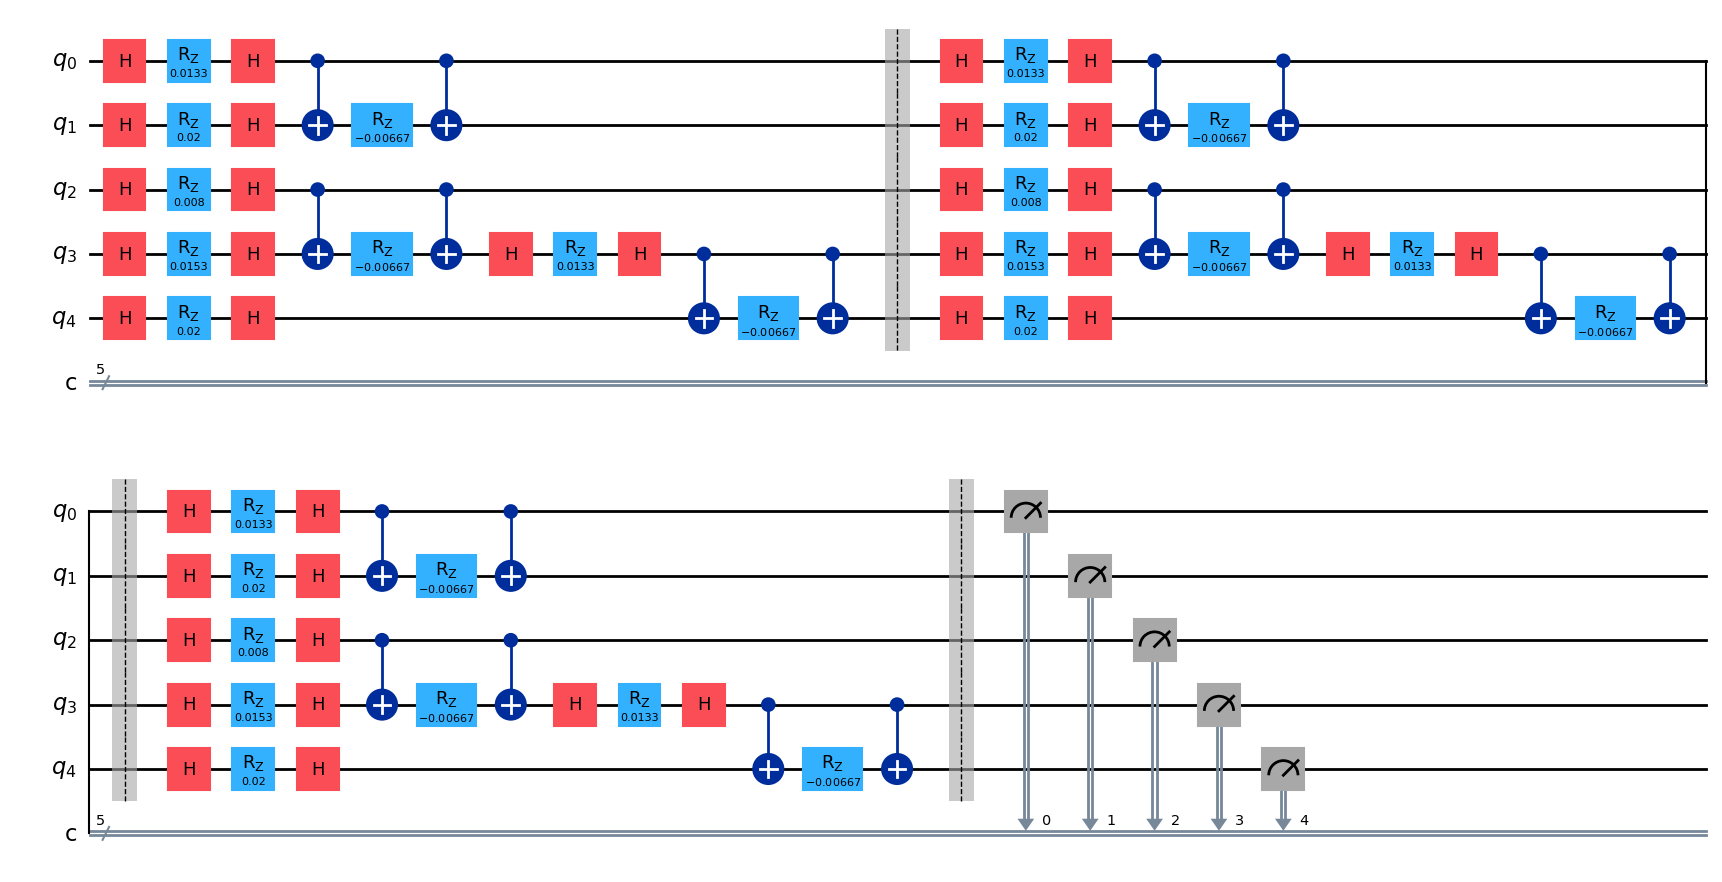

In [4]:
HS_circuit.qc.draw(output='mpl')

## Result, both quantum and classical

In [5]:
## let's see the result of the quantum circuit and classical solver
HS_circuit.show_result()

Quantum Circuit Measurement:
00000: 0.996
00001: 0.0015
00010: 0.001
00011: 0.0
00100: 0.0
00101: 0.0
00110: 0.0
00111: 0.0
01000: 0.0015
01001: 0.0
01010: 0.0
01011: 0.0
01100: 0.0
01101: 0.0
01110: 0.0
01111: 0.0
10000: 0.0
10001: 0.0
10010: 0.0
10011: 0.0
10100: 0.0
10101: 0.0
10110: 0.0
10111: 0.0
11000: 0.0
11001: 0.0
11010: 0.0
11011: 0.0
11100: 0.0
11101: 0.0
11110: 0.0
11111: 0.0
Classical Simulation Measurement:
00000: 0.9958
00001: 0.0009
00010: 0.0018
00011: 0.0000
00100: 0.0001
00101: 0.0000
00110: 0.0000
00111: 0.0000
01000: 0.0009
01001: 0.0000
01010: 0.0000
01011: 0.0000
01100: 0.0000
01101: 0.0000
01110: 0.0000
01111: 0.0000
10000: 0.0004
10001: 0.0000
10010: 0.0000
10011: 0.0000
10100: 0.0000
10101: 0.0000
10110: 0.0000
10111: 0.0000
11000: 0.0000
11001: 0.0000
11010: 0.0000
11011: 0.0000
11100: 0.0000
11101: 0.0000
11110: 0.0000
11111: 0.0000


## Error:

In [6]:
## how much error is there?
print(f"error: {HS_circuit.compare():.8f}")

error: 0.00128547


# Example 2, error~(r, t) relation

In [7]:
r_list = range(15, 100, 3)
t_list = np.linspace(0.001, 1.0, len(r_list))

record_1 = []

for t_temp in tqdm(t_list, desc="Processing t values"):
    result = run_HS(t_temp, 1, Ham_input, shot)
    record_1.append(result[-1])

record_2 = []
for r_temp in tqdm(r_list, desc="Processing r values"):
    result = run_HS(5.0, r_temp, Ham_input, shot)
    record_2.append(result[-1])

Processing r values: 100%|██████████| 29/29 [00:03<00:00,  8.50it/s]


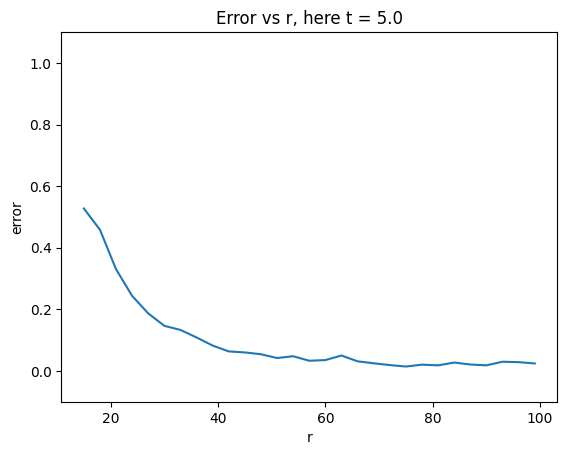

In [8]:
import matplotlib.pyplot as plt

plt.plot(r_list, record_2)
plt.ylim(-0.1, 1.1)
plt.xlabel('r')
plt.ylabel('error')
plt.title('Error vs r, here t = 5.0')

plt.show()

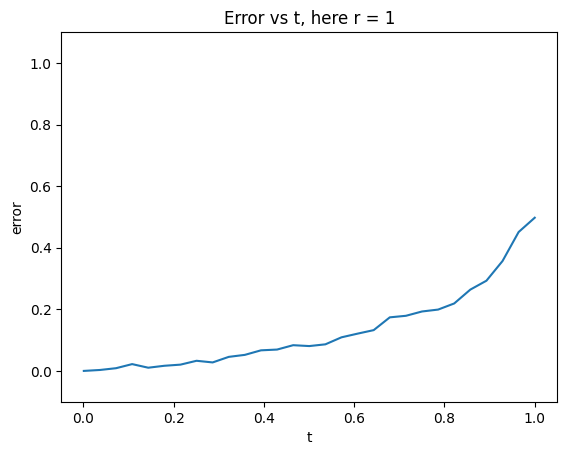

In [9]:
plt.plot(t_list, record_1)
plt.ylim(-0.1, 1.1)
plt.xlabel('t')
plt.ylabel('error')
plt.title('Error vs t, here r = 1')
plt.show()

## Example 3

## First, error~t relation, with fixed r

Processing t values: 100%|██████████| 100/100 [00:03<00:00, 29.13it/s]


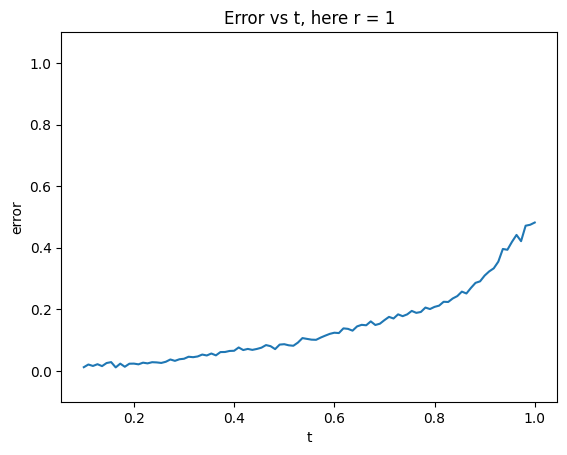

In [10]:
epsilon = 0.01/1
t_list = np.linspace(0.1, 1.0, 100)
record_3 = []
for t_temp in tqdm(t_list, desc="Processing t values"):
    result = run_HS(t_temp, 1, Ham_input, shot)
    record_3.append(result[-1])
plt.plot(t_list, record_3)
plt.ylim(-0.1, 1.1)
plt.xlabel('t')
plt.ylabel('error')
plt.title('Error vs t, here r = 1')

plt.show()

## Second, error~t relation, with r = t^2/epsilon

Processing t values: 100%|██████████| 100/100 [00:07<00:00, 13.08it/s]


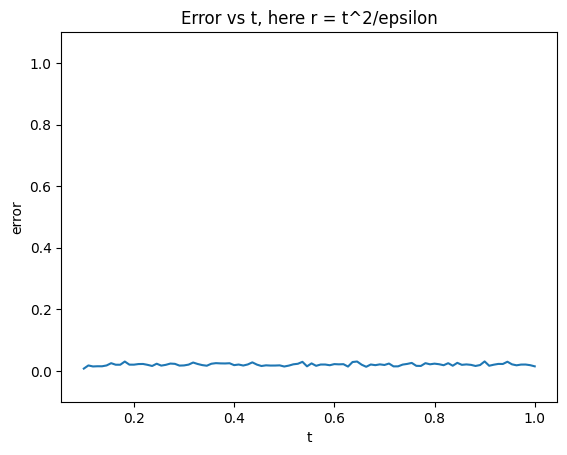

In [11]:
epsilon = 0.01/1
t_list = np.linspace(0.1, 1.0, 100)
record_3 = []
for t_temp in tqdm(t_list, desc="Processing t values"):
    result = run_HS(t_temp, int(t_temp**2/ epsilon), Ham_input, shot)
    record_3.append(result[-1])

plt.plot(t_list, record_3)
plt.ylim(-0.1, 1.1)
plt.xlabel('t')
plt.ylabel('error')
plt.title('Error vs t, here r = t^2/epsilon')

plt.show()

## the actual number of error

In [12]:
print(record_3[-1])

0.01487067446301257


## Example 4 "errorless" Hamiltonian, it is indeed errorless

In [13]:
t = 0.01
r = 3
num_qubit = 5
shot = 2000

## The Hamiltonian is described by a list of tuples, the tuples consist of the Pauli operator and specifications for the Paulis
# Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('gX', 2, 0), ('gX', 3, 1)]
# Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('gX', 2, 0), ('gX', 3, 1), ('ZZ', [3, 4]), ('gX', 2, 3), ('gX', 3, 4), ('ZZ', [2, 3]), ('gX', 1.2, 2), ('gX', 2.3, 3)]
Ham_input = [("Arb", num_qubit),('ZZ', [0, 1]), ('ZZ', [1, 2]), ('ZZ', [2, 3]), ('ZZ', [3, 4])]

"""
The full process is done in four steps: 
1. init the object  (now the object is created but it's emptey), 
2. read the Hamiltonian  (now the circuit is ready but no result is gathered), 
3. get the quantum result  (now we have quantum result but no classical result to compare with), 
4. solve classically  (now all is done, we can compare the result and see if quantum hamiltonian simulation is really good)
"""
HS_circuit = Ham_sim(t, r)
HS_circuit.Ham_reader(Ham_input)
result = HS_circuit.give_result(shot)
H_classical, result_classical, measurement_classical = HS_circuit.solve_classically()

## compressed into one function
def run_HS(t,r,Ham_input, shot):
    HS_circuit = Ham_sim(t, r)
    HS_circuit.Ham_reader(Ham_input)
    result = HS_circuit.give_result(shot)
    H_classical, result_classical, measurement_classical = HS_circuit.solve_classically()
    return HS_circuit, result, result_classical, measurement_classical, HS_circuit.compare()

## let's see what the Hamiltonian is in a more "readable" format
# HS_circuit.print_Ham()
# HS_circuit.qc.draw(output='mpl')
print(f"error: {HS_circuit.compare():.8f}")

error: 0.00000000


^ look, it's zero!